# Chlorophyll vs CDOM 412 (2010-2019)

This notebook generates scatter plots for all available years (2010 - 2019), comparing:

1. **Upwelling Months (May–September) vs. Non-upwelling Months.**
2. **Inside Upwelling (SST < mean - std) vs. Outside Upwelling (inside bounding box but SST ≥ mean - std)**

In [35]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('default')

In [36]:
# Load the data
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]

lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

In [37]:
# Calculate historical pixel-wise mean and std of SST for each month individually
sst_threshold_by_month = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    for m in range(1, 13):
        df_m = df[df.index.month == m]
        if not df_m.empty:
            m_sst = np.stack([np.array(x, dtype=float) for x in df_m['sst']])
            m_mean = np.nanmean(m_sst, axis=0)
            m_std = np.nanstd(m_sst, axis=0)
            sst_threshold_by_month[m] = m_mean - m_std

# Define upwelling zone bounding box
upwelling_lon_min, upwelling_lon_max = -92.20216, -85.61256
upwelling_lat_min, upwelling_lat_max = 19.57871, 22.86906

is_in_bbox = (lon_grid_2d >= upwelling_lon_min) & (lon_grid_2d <= upwelling_lon_max) & \
               (lat_grid_2d >= upwelling_lat_min) & (lat_grid_2d <= upwelling_lat_max)

In [38]:
# Build dataset for all years
results = []

for date_idx, row in df.iterrows():
    month = date_idx.month
    year = date_idx.year

    chlor = row.get('chlorophyll')
    cdom = row.get('cdom_412')
    sst = row.get('sst')

    if chlor is None or cdom is None or sst is None:
        continue
    if isinstance(chlor, float) and np.isnan(chlor):
        continue
    if isinstance(cdom, float) and np.isnan(cdom):
        continue
    if isinstance(sst, float) and np.isnan(sst):
        continue

    chlor_arr = np.array(chlor, dtype=float).flatten()
    cdom_arr = np.array(cdom, dtype=float).flatten()
    sst_arr = np.array(sst, dtype=float).flatten()
    
    bbox_arr = is_in_bbox.flatten()
    
    if month not in sst_threshold_by_month:
        continue
    threshold_arr = np.array(sst_threshold_by_month[month], dtype=float).flatten()
    
    is_upwelling_arr = (sst_arr < threshold_arr)

    valid = ~(np.isnan(chlor_arr) | np.isnan(cdom_arr) | np.isnan(sst_arr)) & bbox_arr
    if not np.any(valid):
        continue

    df_temp = pd.DataFrame({
        'chlor': chlor_arr[valid],
        'cdom412': cdom_arr[valid],
        'upwelling': is_upwelling_arr[valid],
        'month': month,
        'year': year
    })
    results.append(df_temp)

all_data = pd.concat(results, ignore_index=True)
all_data['Zone'] = all_data['upwelling'].map({True: 'Inside Upwelling', False: 'Outside Upwelling'})
all_data['Season'] = all_data['month'].apply(lambda m: 'Upwelling Months (May-Sep)' if 5 <= m <= 9 else 'Non-upwelling Months (Oct-Apr)')
print(f'Total points processed: {len(all_data)}')

Total points processed: 35282834


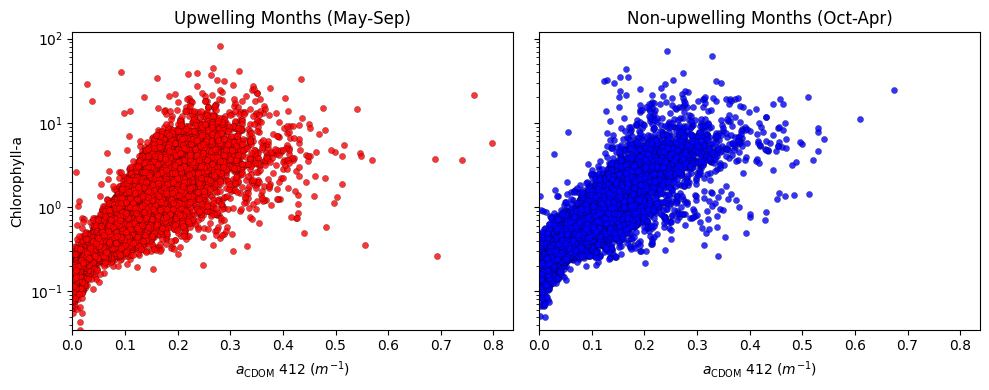

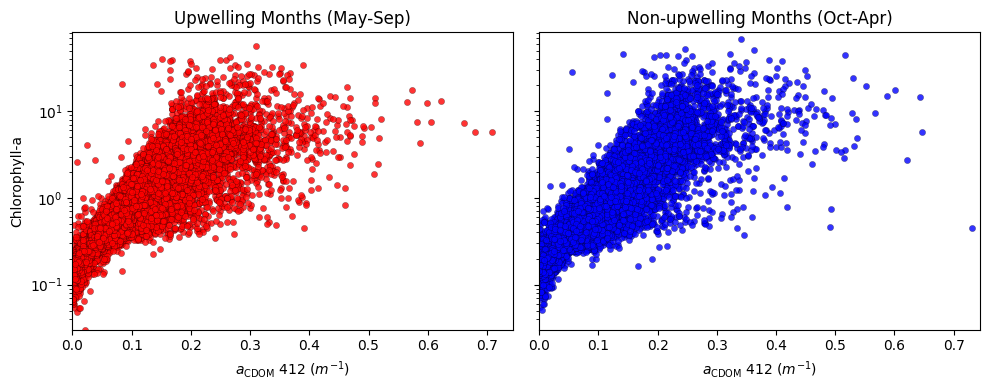

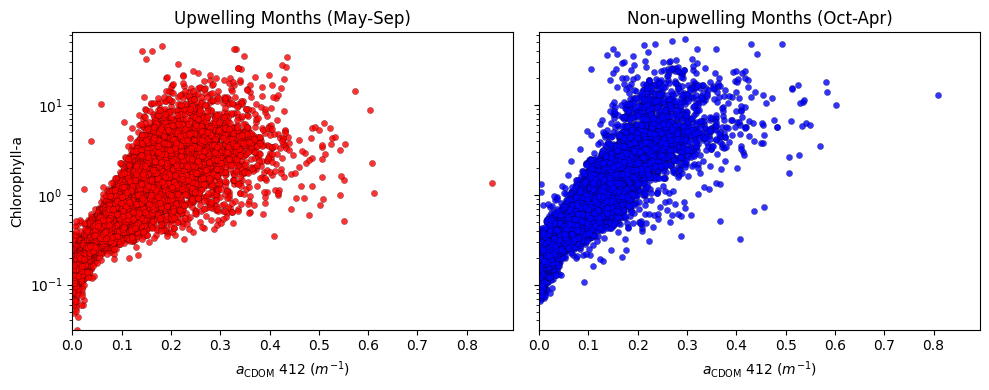

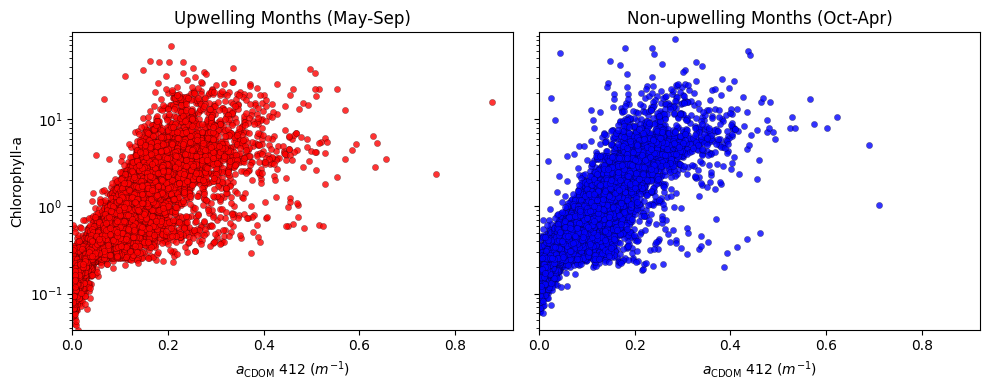

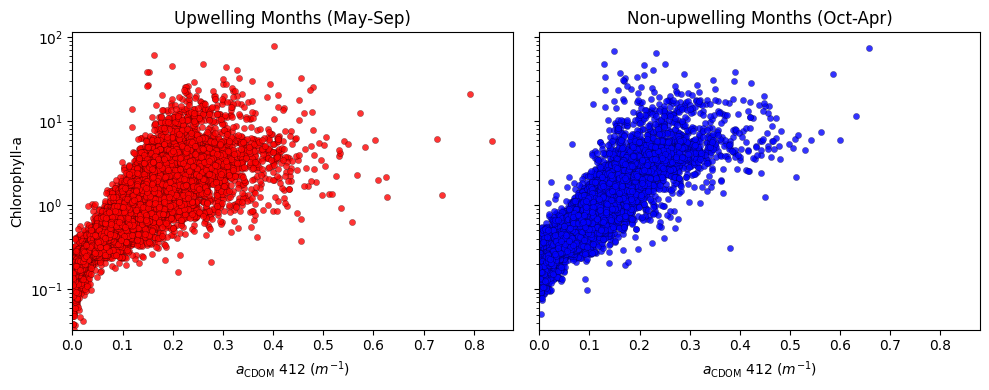

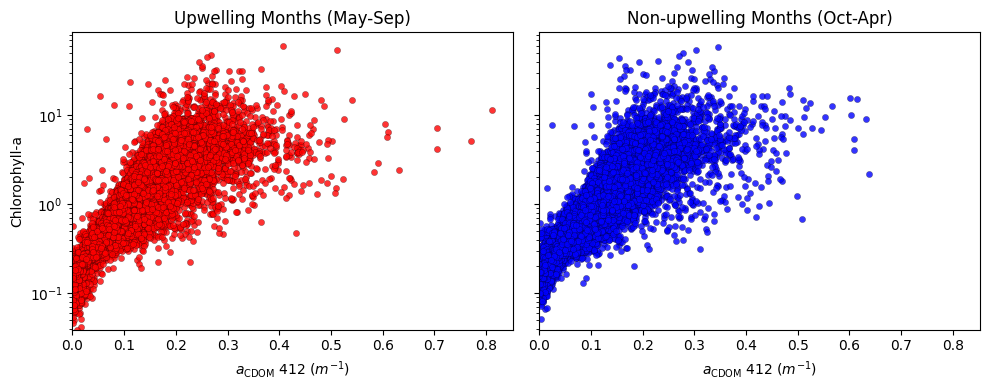

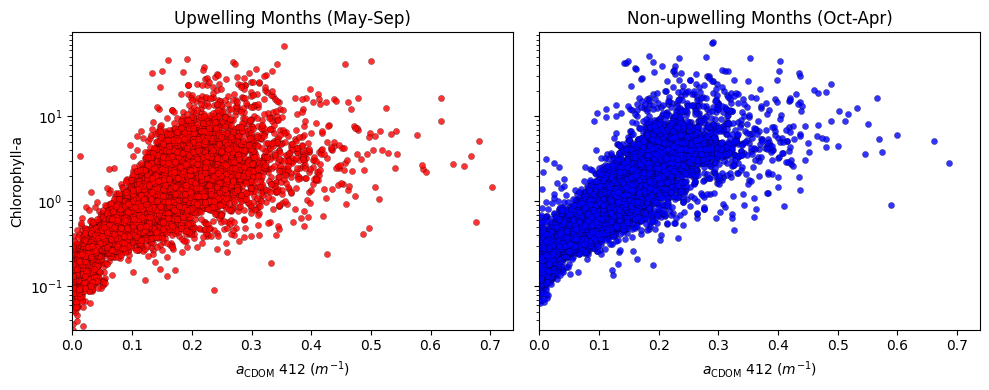

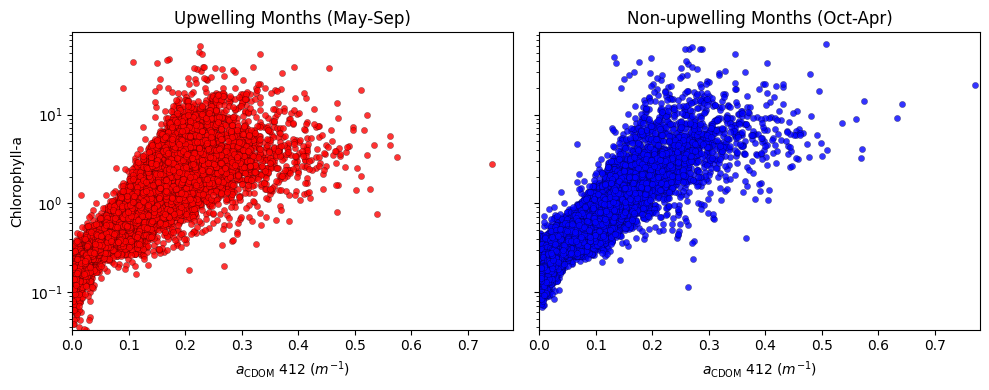

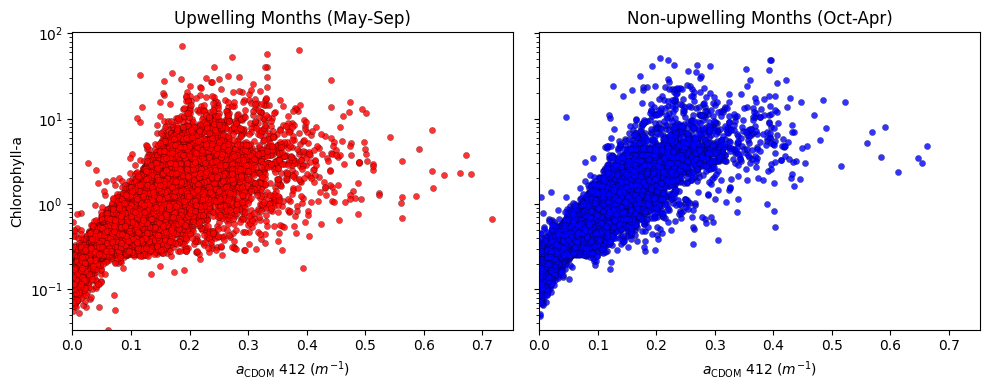

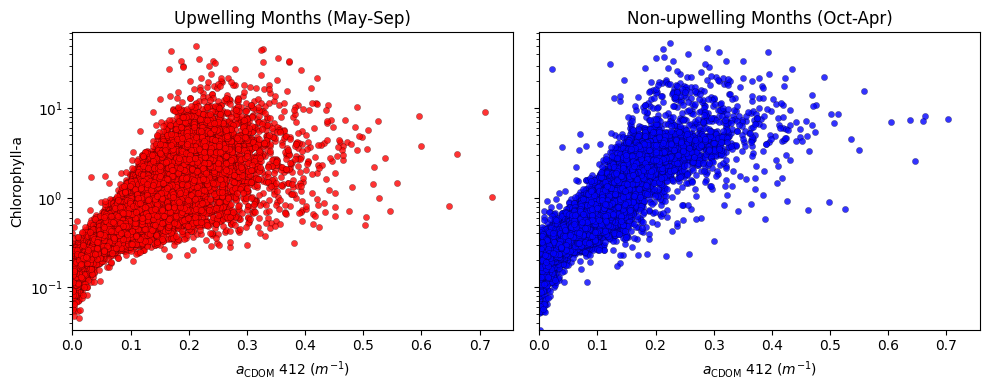

In [39]:
# Figure Type 1: Upwelling Months vs. Non-upwelling Months for each year (2010 - 2019)
import os
output_dir_1 = '../../../figures/chlor_vs_cdom_upwelling_months_2010_2019/'
os.makedirs(output_dir_1, exist_ok=True)

years = sorted(all_data['year'].unique())
max_points = 50000

for year in years:
    year_data = all_data[all_data['year'] == year].copy()
    if year_data.empty:
        continue
    
    # Subsample if necessary
    if len(year_data) > max_points * 2:
        year_data = pd.concat([
            year_data[year_data['Season'] == 'Upwelling Months (May-Sep)'].sample(n=min(len(year_data[year_data['Season'] == 'Upwelling Months (May-Sep)']), max_points), random_state=42),
            year_data[year_data['Season'] == 'Non-upwelling Months (Oct-Apr)'].sample(n=min(len(year_data[year_data['Season'] == 'Non-upwelling Months (Oct-Apr)']), max_points), random_state=42)
        ])

    y_min = year_data['chlor'].min()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

    # Upwelling Months Panel
    sns.scatterplot(
        ax=axes[0],
        data=year_data[year_data['Season'] == 'Upwelling Months (May-Sep)'],
        x='cdom412',
        y='chlor',
        color='red',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[0].set_title('Upwelling Months (May-Sep)')
    axes[0].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[0].set_ylabel('Chlorophyll-a')
    axes[0].set_yscale('log')
    axes[0].set_xlim(left=0)
    axes[0].set_ylim(bottom=y_min)

    # Non-upwelling Months Panel
    sns.scatterplot(
        ax=axes[1],
        data=year_data[year_data['Season'] == 'Non-upwelling Months (Oct-Apr)'],
        x='cdom412',
        y='chlor',
        color='blue',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[1].set_title('Non-upwelling Months (Oct-Apr)')
    axes[1].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[1].set_yscale('log')
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=y_min)

    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_1, f'chlor_vs_cdom_{year}.png'), dpi=300, bbox_inches='tight')
    plt.show()

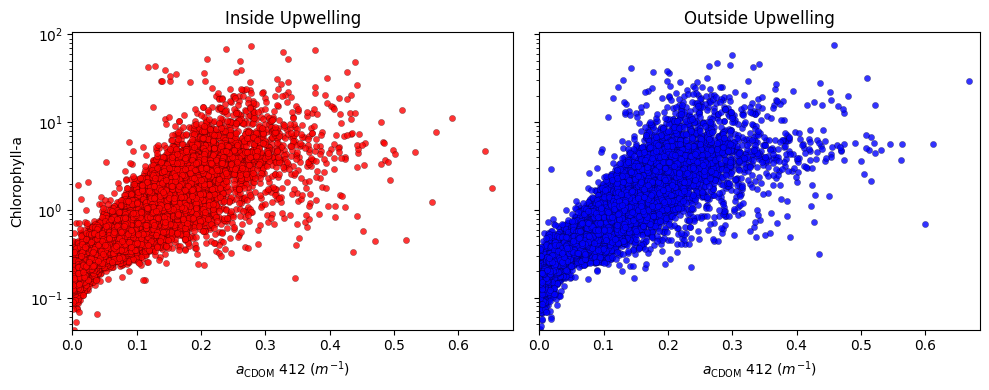

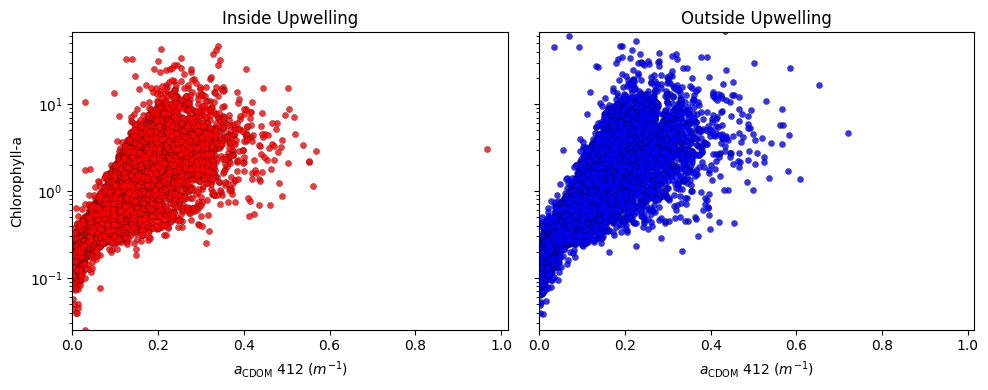

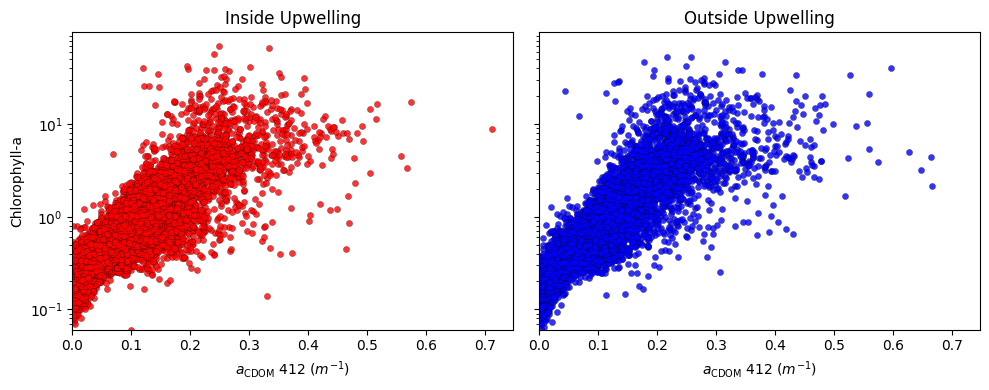

In [40]:
# Figure Type 3: Inside Upwelling (Left) vs Outside Upwelling (Right) - Pooled across all years
import os
output_dir_3 = '../../../figures/chlor_vs_cdom_upwelling_zones_pooled/'
os.makedirs(output_dir_3, exist_ok=True)

max_points_pooled = 50000

# Helper to subsample and plot
def plot_zones(data_subset, title_suffix, filename_suffix):
    # Subsample if necessary
    zone_in = data_subset[data_subset['Zone'] == 'Inside Upwelling']
    zone_out = data_subset[data_subset['Zone'] == 'Outside Upwelling']
    
    if len(zone_in) > max_points_pooled:
        zone_in = zone_in.sample(n=max_points_pooled, random_state=42)
    if len(zone_out) > max_points_pooled:
        zone_out = zone_out.sample(n=max_points_pooled, random_state=42)
        
    y_min = min(zone_in['chlor'].min(), zone_out['chlor'].min())
        
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    
    # Inside Upwelling (Left)
    sns.scatterplot(
        ax=axes[0],
        data=zone_in,
        x='cdom412',
        y='chlor',
        color='red',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[0].set_title('Inside Upwelling')
    axes[0].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[0].set_ylabel('Chlorophyll-a')
    axes[0].set_yscale('log')
    axes[0].set_xlim(left=0)
    axes[0].set_ylim(bottom=y_min)
    
    # Outside Upwelling (Right)
    sns.scatterplot(
        ax=axes[1],
        data=zone_out,
        x='cdom412',
        y='chlor',
        color='blue',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[1].set_title('Outside Upwelling')
    axes[1].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[1].set_yscale('log')
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=y_min)
    
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_3, f'chlor_vs_cdom_{filename_suffix}.png'), dpi=300, bbox_inches='tight')
    plt.show()

# 1. Pooled across all years and seasons
plot_zones(all_data, 'All Years & Seasons', 'all_years_all_seasons')

# 2. Upwelling months only
plot_zones(all_data[all_data['Season'] == 'Upwelling Months (May-Sep)'], 
           'All Years (Upwelling Months)', 'all_years_upwelling_months')
           
# 3. Non-upwelling months only
plot_zones(all_data[all_data['Season'] == 'Non-upwelling Months (Oct-Apr)'], 
           'All Years (Non-upwelling Months)', 'all_years_nonupwelling_months')

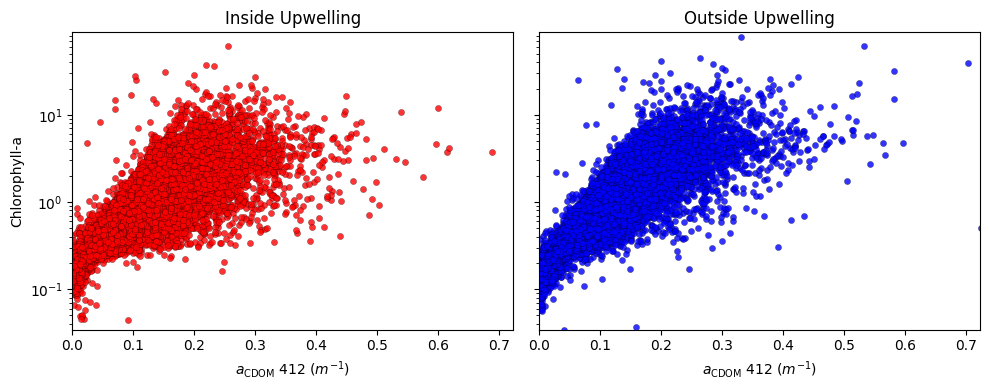

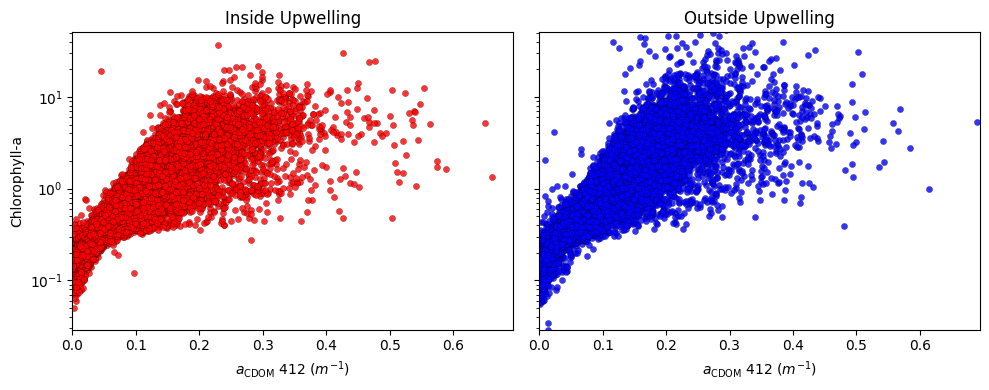

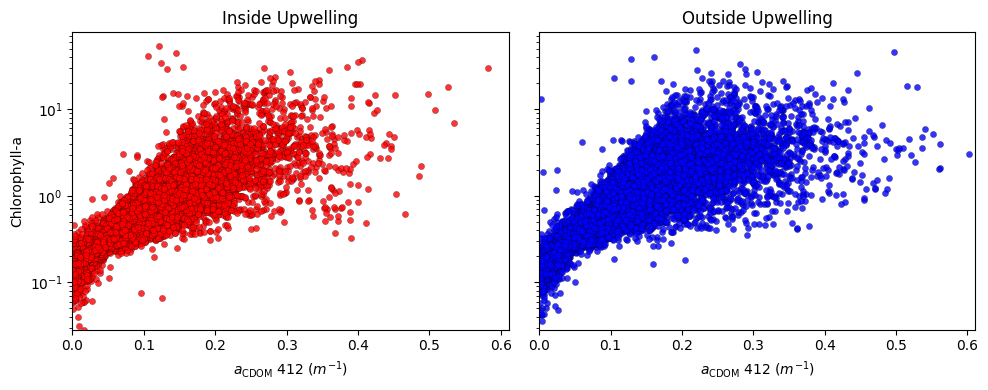

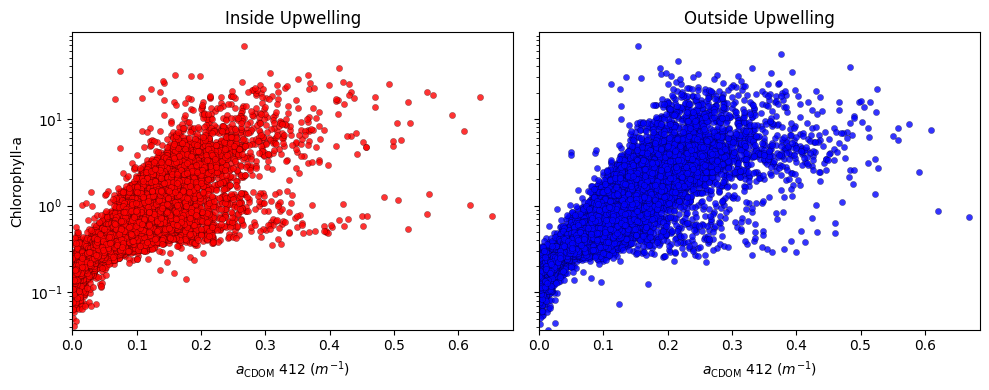

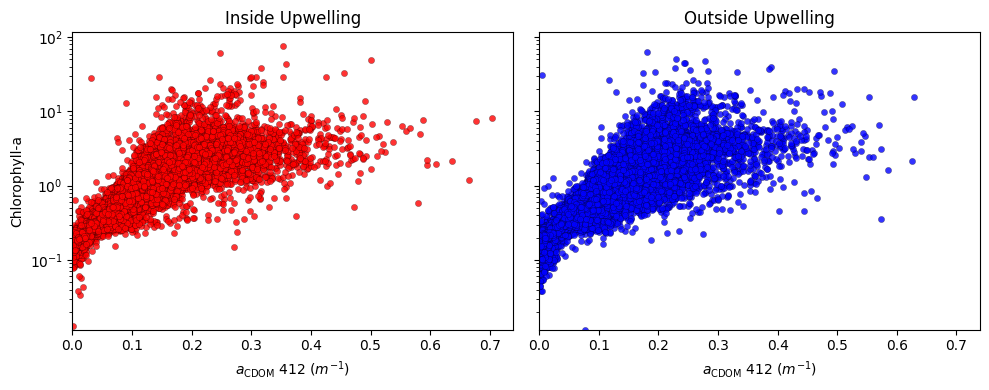

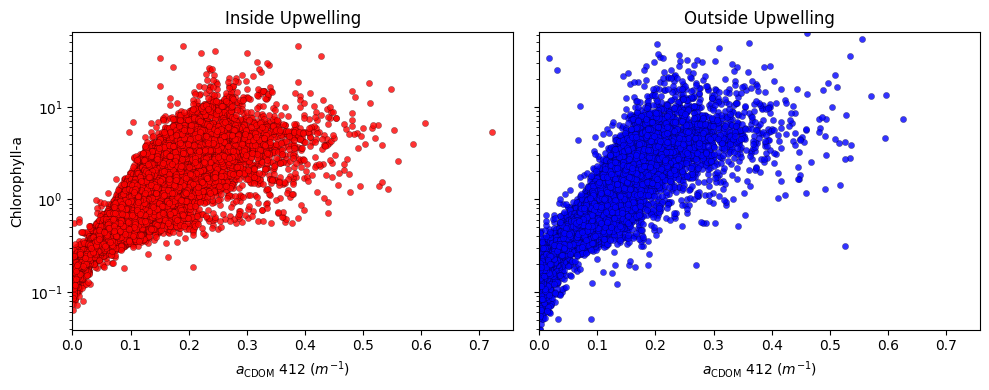

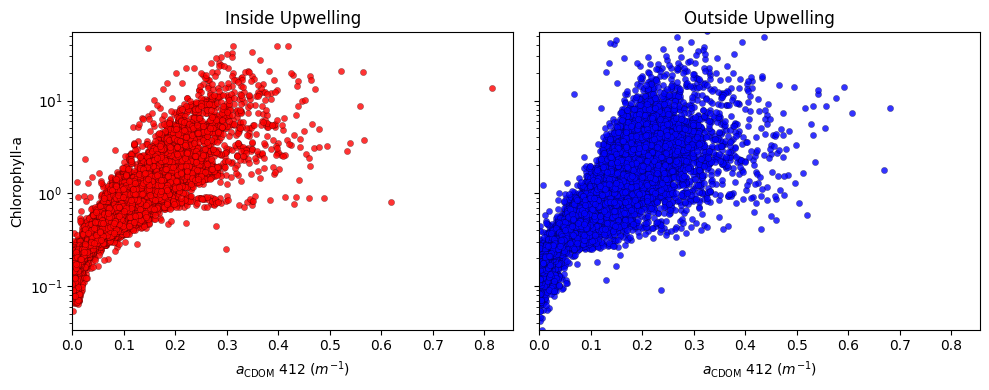

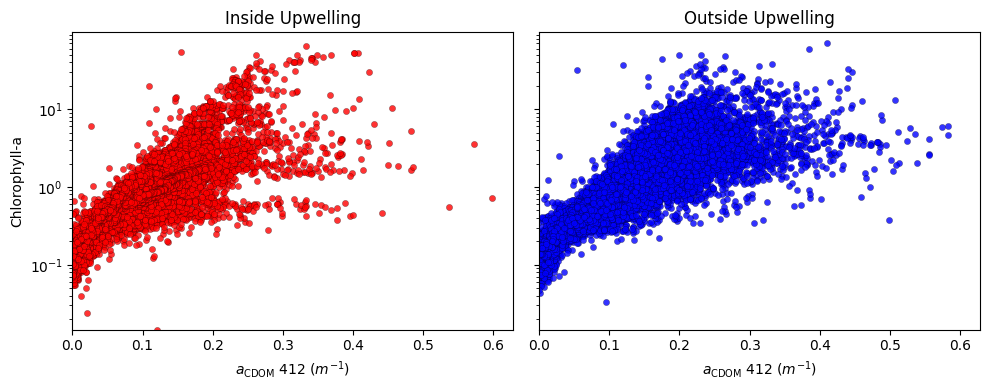

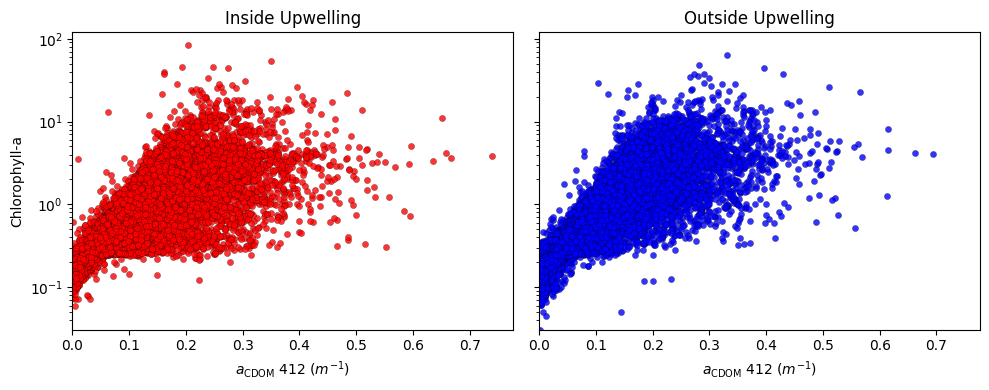

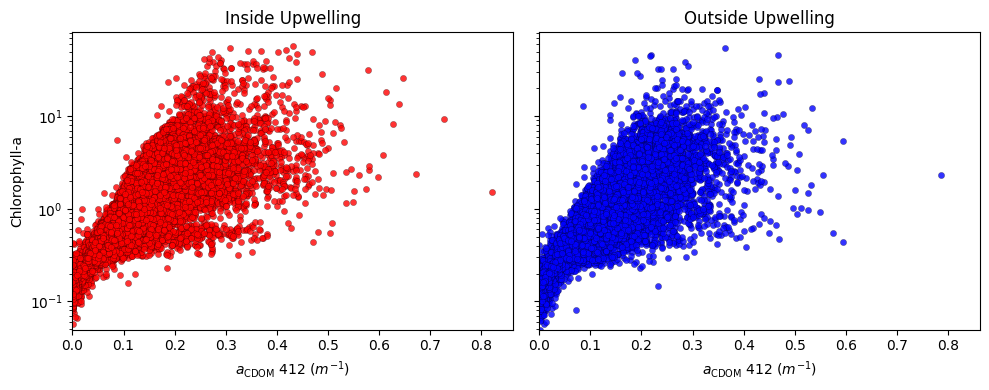

In [41]:
# Figure Type 4: Inside Upwelling vs Outside Upwelling during Upwelling Months (May-Sep) for each year
import os
output_dir_4 = '../../../figures/chlor_vs_cdom_upwelling_zones_yearly/'
os.makedirs(output_dir_4, exist_ok=True)

years = sorted(all_data['year'].unique())
max_points = 50000

for year in years:
    year_data = all_data[(all_data['year'] == year) & (all_data['Season'] == 'Upwelling Months (May-Sep)')].copy()
    if year_data.empty:
        continue
    
    # Subsample if necessary
    zone_in = year_data[year_data['Zone'] == 'Inside Upwelling']
    zone_out = year_data[year_data['Zone'] == 'Outside Upwelling']
    
    if len(zone_in) > max_points:
        zone_in = zone_in.sample(n=max_points, random_state=42)
    if len(zone_out) > max_points:
        zone_out = zone_out.sample(n=max_points, random_state=42)
        
    y_min = min(zone_in['chlor'].min(), zone_out['chlor'].min())
        
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    
    # Inside Upwelling (Left)
    sns.scatterplot(
        ax=axes[0],
        data=zone_in,
        x='cdom412',
        y='chlor',
        color='red',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[0].set_title('Inside Upwelling')
    axes[0].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[0].set_ylabel('Chlorophyll-a')
    axes[0].set_yscale('log')
    axes[0].set_xlim(left=0)
    axes[0].set_ylim(bottom=y_min)
    
    # Outside Upwelling (Right)
    sns.scatterplot(
        ax=axes[1],
        data=zone_out,
        x='cdom412',
        y='chlor',
        color='blue',
        alpha=0.8,
        marker='o',
        s=20,
        linewidth=0.2,
        edgecolor='black'
    )
    axes[1].set_title('Outside Upwelling')
    axes[1].set_xlabel(r'$a_{\text{CDOM}}$ 412 $(m^{-1})$')
    axes[1].set_yscale('log')
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=y_min)
    
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_4, f'chlor_vs_cdom_upwelling_months_{year}.png'), dpi=300, bbox_inches='tight')
    plt.show()